<a href="https://colab.research.google.com/github/AYCDJ/Monkeytype-Data/blob/main/Monkeytype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This Notebook is being made in order to provide analysis and document my typing data from Monkeytype, a typing platform made to help improve typing speed and accuracy.

I only have access to data entries ~34,000 and above because Monkeytype only keeps track of the last 1000 tests.

In [1]:
# Access to google drive

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Variables for future use

DRIVE_FOLDER_PATH = '/content/drive/MyDrive/Colab Notebooks/monkeytype' # If using this notebook you will need to update this with the path in your own drive, (CASE SENSITIVE)
TIMEZONE = 'America/Chicago'  # Can be updated to display your own if different
EXPORT_FOLDER_PATH = '/content/drive/MyDrive/Colab Notebooks/MonkeytypeModelFile' # If using this notebook you will need to update this with the path in your own drive, (CASE SENSITIVE)


In [3]:
# Imports and colors for style

import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import warnings
warnings.filterwarnings('ignore')

# These colors were chosen in order to resemble my chosen theme in monkeytype, seen below
'''
https://monkeytype.com/settings?highlight=theme
:root {
    --bg-color: #1c1e26;
    --main-color: #c4a88a;
    --caret-color: #bbbbbb;
    --sub-color: #db886f;
    --sub-alt-color: #17181f;
    --text-color: #bbbbbb;
    --error-color: #d55170;
    --error-extra-color: #ff3d3d;
    --colorful-error-color: #d55170;
    --colorful-error-extra-color: #d55170;
}
'''

MCOLOR      = '#c4a88a'  # Main color
SCOLOR      = '#db886f'  # Sub colro
BG          = '#1c1e26'  # Background color
PANEL       = '#17181f'
TCOLOR      = '#d1d0c5'  # Text color
ERROR_COLOR = '#d55170'
GREY        = '#bbbbbb'
WHITE       = '#ffffff'

# Style configuration, customizes BG color, gridlines, tick colors etc.
plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   PANEL,
    'axes.edgecolor':   '#2a2a2a',
    'axes.labelcolor':  SCOLOR,
    'xtick.color':      SCOLOR,
    'ytick.color':      SCOLOR,
    'text.color':       TCOLOR,
    'grid.color':       '#232323',
    'grid.linestyle':   '-',
    'grid.linewidth':   0.6,
    'axes.grid':        True,
    'axes.grid.axis':   'y',
    'font.family':      'monospace',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

# Function to apply consistent title style
def title(ax, text):
    ax.set_title(text, color=MCOLOR, fontsize=13, pad=10, loc='left')

#

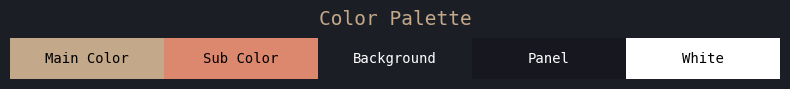

In [4]:
# The following is just to view colors, no need to run code

fig, ax = plt.subplots(figsize=(8, 1))

colors = [MCOLOR, SCOLOR, BG, PANEL, WHITE]
labels = ['Main Color', 'Sub Color', 'Background', 'Panel', 'White']
x_pos = np.arange(len(colors))

ax.barh(0, [1]*len(colors), color=colors, height=1)
ax.set_yticks([])
ax.set_xticks(x_pos + 0.5)
ax.set_xticklabels(labels, color=TCOLOR)
ax.set_xlim(0, len(colors))
ax.set_facecolor(BG)
ax.tick_params(axis='x', colors=TCOLOR)

# Individual widths and positions for seperation/labeling
widths = [1] * len(colors)
starts = np.arange(len(colors))

for i, color in enumerate(colors):
  rect = plt.Rectangle((starts[i], -0.5), widths[i], 1, facecolor=color)
  ax.add_patch(rect)
  ax.text(starts[i] + widths[i]/2, 0, labels[i], ha='center', va='center', color='white' if color in [BG, PANEL] else 'black', fontsize = 10)

ax.set_xlim(0, len(colors))
ax.set_ylim(-0.5, 0.5)
ax.axis('off')

plt.title('Color Palette', color=MCOLOR, fontsize=14, pad=10)
plt.tight_layout()
plt.show()

In [5]:
# Loading and removing duplicate entries

csv_files = sorted(glob.glob(os.path.join(DRIVE_FOLDER_PATH, '*.csv')))
print(f'Found {len(csv_files)} files:')
for f in csv_files:
    print(f' {os.path.basename(f)}')

if not csv_files:
    raise FileNotFoundError(f'No CSV files in: {DRIVE_FOLDER_PATH}')

raw = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
print(f'\nTotal rows: {len(raw):,}')

df = raw.drop_duplicates(subset=['_id']).copy()
print(f'Total rows after removing duplicates: {len(df):,}')
print(f'Total rows removed: {len(raw) - len(df):,}')

Found 4 files:
 01results.csv
 02results.csv
 03results.csv
 04results.csv

Total rows: 4,004
Total rows after removing duplicates: 3,411
Total rows removed: 593


In [6]:
# Parsing data and cleaning, timestamps are in Unix milliseconds

df['date'] = (pd.to_datetime(df['timestamp'], unit='ms', utc = True)
              .dt.tz_convert(TIMEZONE))
df = df.sort_values('date').reset_index(drop=True)

# Stats, format is - correct;incorrect;extra;missed
char_parts = df['charStats'].str.split(';', expand=True).astype(float)
df['chars_correct']     = char_parts[0]
df['chars_incorrect']   = char_parts[1]
df['chars_extra']       = char_parts[2]
df['chars_missed']      = char_parts[3]
df['chars_total']       = df[['chars_correct', 'chars_incorrect', 'chars_extra', 'chars_missed']].sum(axis=1)

# Columns
df['mode_label'] = df['mode'] + ' ' + df['mode2'].astype(str)
df['test_num']   = range(1, len(df) + 1)
df['week']       = df['date'].dt.to_period('W')
df['day']        = df['date'].dt.date

# Rolling average
N = max(10, len(df) // 30)
df['wpm_roll']  = df['wpm'].rolling(N, min_periods=1).mean()
df['acc_roll']  = df['acc'].rolling(N, min_periods=1).mean()
df['raw_roll']  = df['rawWpm'].rolling(N, min_periods=1).mean()
df['cons_roll'] = df['consistency'].rolling(N, min_periods=1).mean()

print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Total tests: {len(df):,}')
print(f'Rolling window: {N} tests')
Temp = df[['wpm','acc','rawWpm','consistency','restartCount', 'testDuration']].describe().round(2)
display(Temp.drop('count'))

Date range: 2026-05-04 to 2026-06-07
Total tests: 3,411
Rolling window: 113 tests


,wpm,acc,rawWpm,consistency,restartCount,testDuration
mean,112.01,94.59,117.50,75.16,0.0,15.09
std,10.21,2.74,9.75,6.13,0.0,2.28
min,81.64,83.94,87.26,51.01,0.0,3.72
25%,104.87,92.79,110.47,70.91,0.0,14.99
50%,112.04,94.77,117.65,75.15,0.0,14.99
75%,119.25,96.66,124.08,79.31,0.0,14.99
max,164.52,100.00,164.52,96.92,0.0,119.99


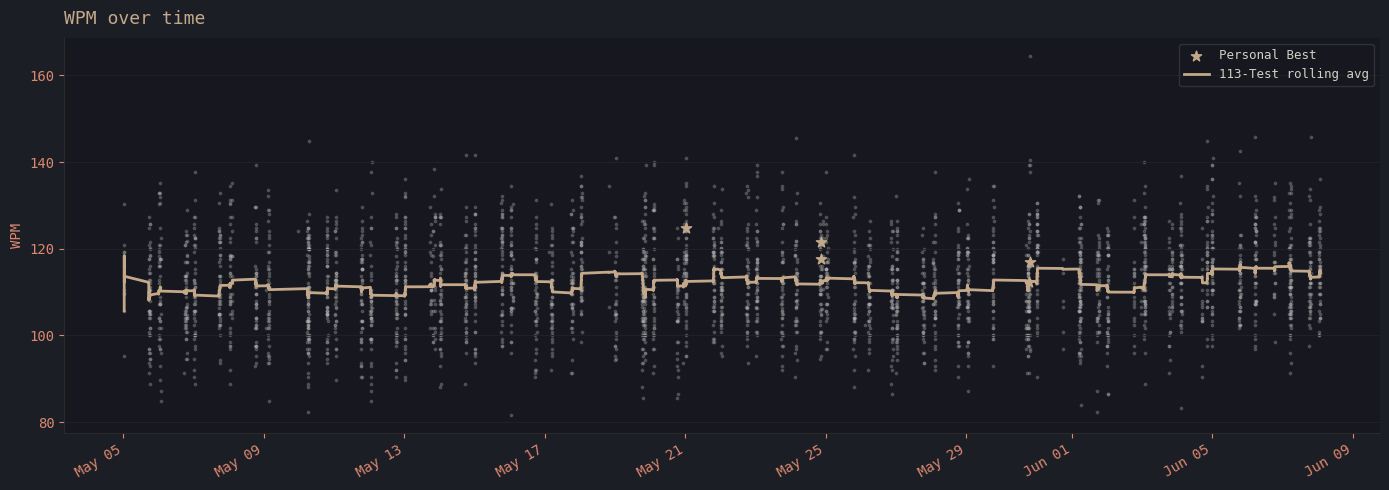

In [7]:
# WPM Progress

fig, ax = plt.subplots(figsize=(14, 5))

# Personal best
pb_mask = df['isPb'] == True
ax.scatter(df.loc[pb_mask, 'date'], df.loc[pb_mask, 'wpm'], s=60, color=MCOLOR, zorder=5, marker='*', label='Personal Best')

ax.scatter(df['date'], df['wpm'], s=3, alpha=0.25, color=GREY, zorder=1)
ax.plot(df['date'], df['wpm_roll'], color=MCOLOR, lw=2, label=f'{N}-Test rolling avg')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=30, ha='right')
ax.set_ylabel('WPM')
title(ax, 'WPM over time')
ax.legend(framealpha=0.15, fontsize=9)
plt.tight_layout()
plt.show()

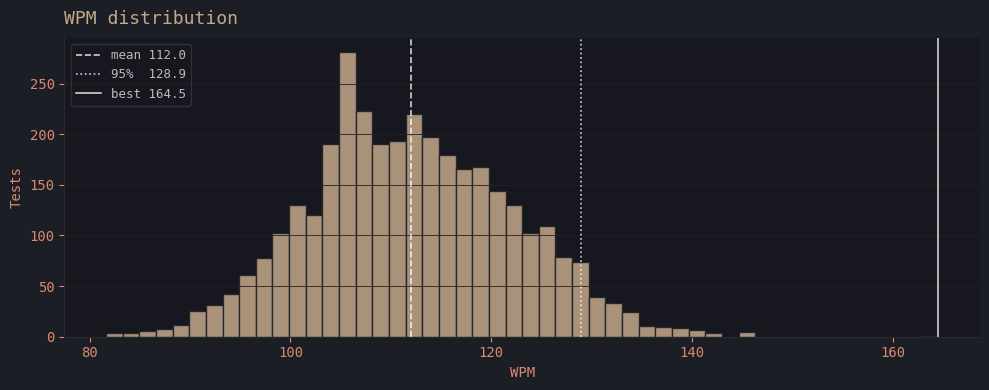

In [8]:
# WPM Distribution

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["wpm"].dropna(), bins=50, color=MCOLOR, alpha=0.85, edgecolor=BG) # If you want more/less columns change the 'bins' value to the amount you want

stats = {
    f"mean {df['wpm'].mean():.1f}": (df['wpm'].mean(), '--'),
    f"95%  {df['wpm'].quantile(0.95):.1f}": (df['wpm'].quantile(0.95), ':'),
    f"best {df['wpm'].max():.1f}": (df['wpm'].max(), '-'),
}
for label, (val, ls) in stats.items():
    ax.axvline(val, color=WHITE, lw=1.2, ls=ls, alpha=0.8, label=label)

ax.set_xlabel('WPM')
ax.set_ylabel('Tests')
title(ax, 'WPM distribution')
ax.legend(framealpha=0.15, fontsize=9, labelcolor=GREY)
plt.tight_layout()
plt.show()



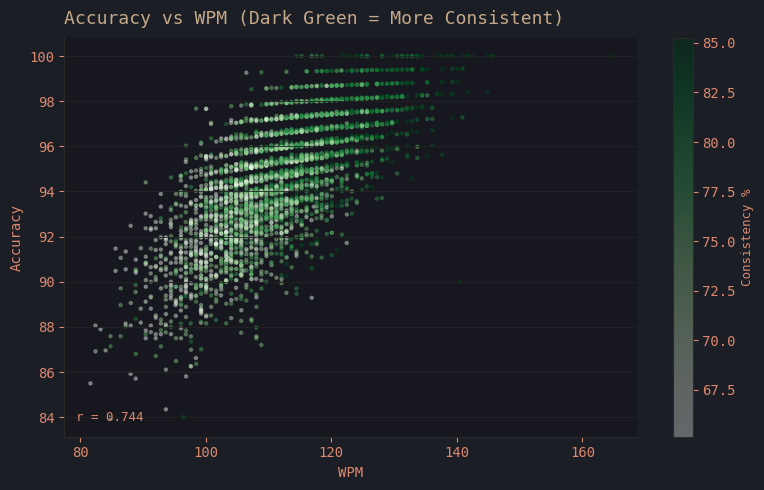

In [9]:
# Accuracy vs WPM

fig, ax = plt.subplots(figsize=(8, 5))

# cmap value controls the color of the graph/plotted values, I like Greens, unfortunately I dont think it matches the theme. In terms of matching colors I think copper isnt a bad choice.
sc = ax.scatter(df['wpm'], df['acc'], s=5, alpha=0.35, c=df['consistency'], cmap='Greens', vmin=df['consistency'].quantile(0.05), vmax=df['consistency'].quantile(0.95))
cb = plt.colorbar(sc, ax=ax)
cb.set_label('Consistency %', color=SCOLOR, fontsize=9)
cb.ax.yaxis.set_tick_params(color=SCOLOR)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=SCOLOR)

corr = df[['wpm', 'acc']].dropna().corr().iloc[0,1]
ax.text(0.02, 0.04, f'r = {corr:.3f}', transform=ax.transAxes, color=SCOLOR, fontsize=9)

ax.set_xlabel('WPM')
ax.set_ylabel('Accuracy')
title(ax, 'Accuracy vs WPM (Dark Green = More Consistent)')
plt.tight_layout()
plt.show()

#

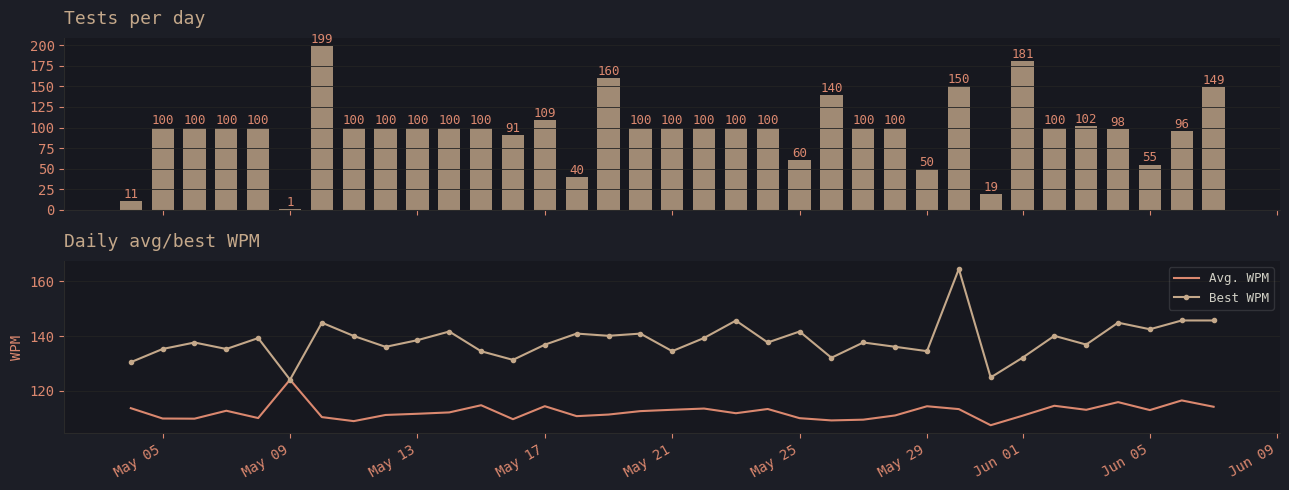

In [10]:
# Tests per day + wpm

daily_df = df.groupby('day').agg(
    tests=('wpm', 'count'),
    wpm=('wpm', 'mean'),
    best_wpm=('wpm', 'max'),
).reset_index()
daily_df['day'] = pd.to_datetime(daily_df['day'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 5), sharex=True)

bars = ax1.bar(daily_df['day'], daily_df['tests'], color=MCOLOR, width=0.7, alpha=0.8)
title(ax1, 'Tests per day')
ax1.set_label('Tests')
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))

for bar in bars:
  yval = bar.get_height()
  ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), ha='center', va='bottom', color=SCOLOR, fontsize=9)

ax2.plot(daily_df['day'], daily_df['wpm'], color=SCOLOR, lw=1.5, label='Avg. WPM')
ax2.plot(daily_df['day'], daily_df['best_wpm'], color=MCOLOR, lw=1.5, marker='o', markersize=3, label='Best WPM')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=30, ha='right')
ax2.set_ylabel('WPM')
title(ax2, 'Daily avg/best WPM')
ax2.legend(framealpha=0.15, fontsize=9)
plt.tight_layout()
plt.show()



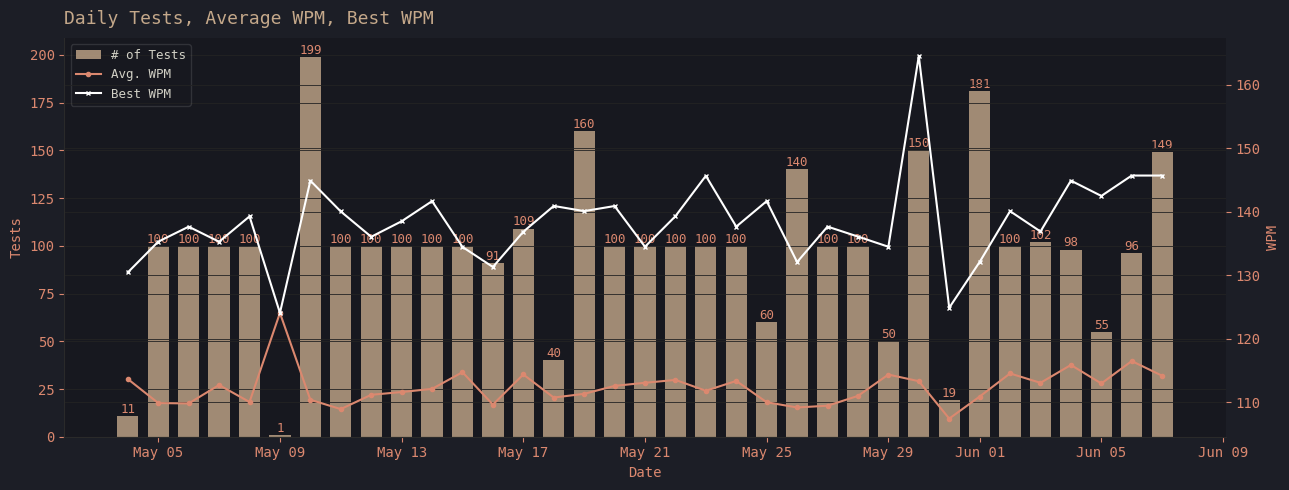

In [11]:
# Both figures overlayed over each other, not nessecary to run this cell
# Including this code snippet in this cell as well ensures that the previous cell isnt required to run in order for this cell to work
# The color of the Best WPM is a little off in the combined graph so I changed it to be white

daily_df = df.groupby('day').agg(
    tests=('wpm', 'count'),
    wpm=('wpm', 'mean'),
    best_wpm=('wpm', 'max'),
).reset_index()
daily_df['day'] = pd.to_datetime(daily_df['day'])

fig, ax1 = plt.subplots(figsize=(13, 5))

bars = ax1.bar(daily_df['day'], daily_df['tests'], color=MCOLOR, width=0.7, alpha=0.8, label='# of Tests')
ax1.set_xlabel('Date')
ax1.set_ylabel('Tests', color=SCOLOR)
ax1.tick_params(axis='y', labelcolor=SCOLOR)
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))

ax2 = ax1.twinx()
ax2.plot(daily_df['day'], daily_df['wpm'], color=SCOLOR, lw=1.5, marker='o', markersize = 3, label='Avg. WPM')
ax2.plot(daily_df['day'], daily_df['best_wpm'], color=WHITE, lw=1.5, marker='x', markersize=3, label='Best WPM')
ax2.set_ylabel('WPM', color=SCOLOR)
ax2.tick_params(axis='y', labelcolor=SCOLOR)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=30, ha='right')

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc = 'upper left', framealpha=0.15, fontsize=9)

# Addds labels above each bar
for bar in bars:
  yval = bar.get_height()
  ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), ha='center', va='bottom', color=SCOLOR, fontsize=9)

title(ax1, 'Daily Tests, Average WPM, Best WPM')
plt.tight_layout()
plt.show()

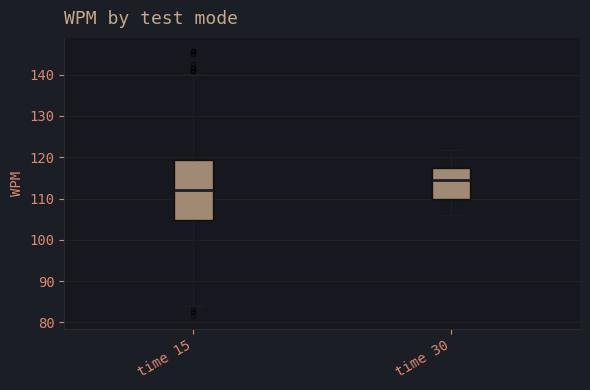

In [12]:
# WPM by test mode

mode_counts = df['mode_label'].value_counts()
top_modes = mode_counts[mode_counts >= 10].index.tolist()

if len(top_modes) > 1:
  groups = [df[df['mode_label'] == m]['wpm'].dropna() for m in top_modes]
  fig, ax = plt.subplots(figsize=(max(6, len(top_modes)*1.5), 4))
  bp = ax.boxplot(groups, labels=top_modes, patch_artist=True, medianprops=dict(color=BG, lw=2), whiskerprops=dict(color=BG), capprops=dict(color=BG), flierprops=dict(marker='.', color=BG, alpha=0.4))
  for patch in bp['boxes']:
    patch.set_facecolor(MCOLOR)
    patch.set_alpha(0.8)
  plt.xticks(rotation=30, ha='right')
  ax.set_ylabel('WPM')
  title(ax, 'WPM by test mode')
  plt.tight_layout()
  plt.show()
else:
  print('All tests are the same type of test, comparison not shown')

# i just realized i dont have any tests in this dataset that arent time 15. i gues i have to get those now

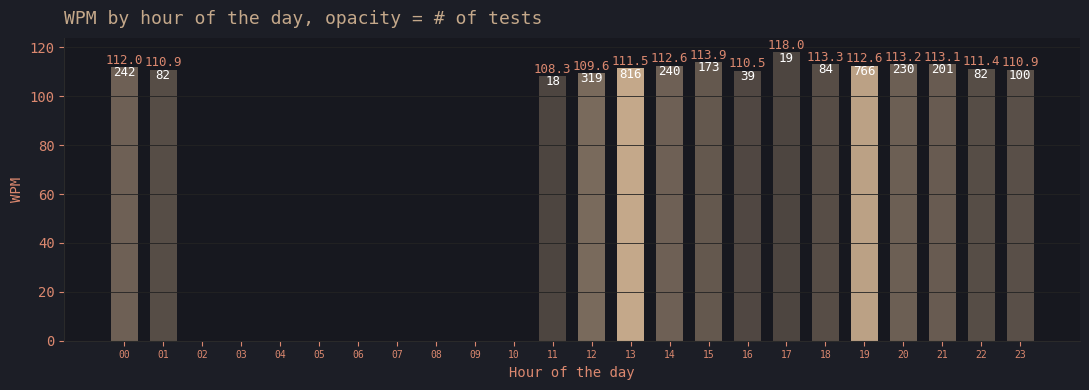

In [13]:
# Performance by hour

df['hour'] = df['date'].dt.hour
hourly = df.groupby('hour')['wpm'].agg(['mean','count'])

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(hourly.index, hourly['mean'], color=MCOLOR, width=0.7, alpha=0.8)

# Bar shading, transparent = less tests
max_c = hourly['count'].max()
for bar, cnt in zip(bars, hourly['count']):
  bar.set_alpha(0.3 + 0.7 * cnt / max_c)

title(ax, 'WPM by hour of the day, opacity = # of tests')
ax.set_xlabel('Hour of the day')
ax.set_ylabel('WPM')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}' for h in range(24)], fontsize = 7)

# This adds a label on top of each bar that displays the avg wpm
for bar in bars:
  yval = bar.get_height()
  ax.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.1f}', ha='center', va='bottom', color=SCOLOR, fontsize=9)

# This adds a label near the top of each bar, below the previous label, that shows the number of tests
for h, row in hourly.iterrows():
  if row['count'] > 0:
    ax.text(h, row['mean'] + 0.3, str(int(row['count'])), ha='center', va='top', color=WHITE, fontsize=9)

plt.tight_layout()
plt.show()

In [14]:
# Summary of personal bests

print('Personal Bests')
print('--' * 27)

for col, label in [('wpm', 'WPM'), ('acc', 'Accuracy'), ('rawWpm', 'Raw WPM'), ('consistency', 'Consistency')]:
  if col not in df.columns:
    continue
  idx = df[col].idxmax(skipna = True)
  val = df.loc[idx, col]
  date = df.loc[idx, 'date'].strftime('%Y-%m-%d %H:%M')
  mode = df.loc[idx, 'mode_label']
  print(f'{label:<14}: {val:>7.2f} on {date} in {mode}')

print(f'\nTotal tests           : {len(df):,}')
print(f'Marked as PB          : {df["isPb"].sum():,}')
print(f'Date range            : {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Avg restarts per test : {df["restartCount"].mean():.2f}')
print(f'Avg test duration     : {df["testDuration"].mean():.2f}s')


Personal Bests
------------------------------------------------------
WPM           :  164.52 on 2026-05-30 14:17 in words 10
Accuracy      :  100.00 on 2026-05-06 19:38 in time 15
Raw WPM       :  164.52 on 2026-05-30 14:17 in words 10
Consistency   :   96.92 on 2026-05-30 14:17 in words 10

Total tests           : 3,411
Marked as PB          : 5
Date range            : 2026-05-04 to 2026-06-07
Avg restarts per test : 0.00
Avg test duration     : 15.09s


In [15]:
# Export comblined CSV file

out = os.path.join(EXPORT_FOLDER_PATH, 'monkeytype_data_combined.csv')
df.to_csv(out, index=False)
print(f'Saved {len(df):,} data entries to: \n{out}')

Saved 3,411 data entries to: 
/content/drive/MyDrive/Colab Notebooks/MonkeytypeModelFile/monkeytype_data_combined.csv
